# Final Project 2: Customer-Style Segmentation

            ## 1. Learning objectives

            - Build a reproducible segmentation workflow
- Compare hard and probabilistic clustering
- Profile and critique the selected groups

            ## 2. Prerequisites

            Complete the corresponding numbered course section and understand leakage-safe train/validation/test roles.

In [1]:
from pathlib import Path
import sys

project_root = next(
    path for path in (Path.cwd(), *Path.cwd().parents)
    if (path / "pyproject.toml").exists()
)
if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

from src.notebook_utils import RANDOM_SEED, set_seed
from src.plotting import COURSE_COLORS, set_course_style

set_seed(RANDOM_SEED)
set_course_style()
rng = np.random.default_rng(RANDOM_SEED)
print(f"Python lesson ready; reproducible seed = {RANDOM_SEED}")

Python lesson ready; reproducible seed = 42


## 3. Problem definition

            Use wine chemistry as a safe proxy for customer-style segmentation. Success requires compact groups plus interpretable profiles, not a hidden answer label.

            ## 4. Real-world use cases

            - Exploratory segmentation
- Persona research inputs
- Assortment analysis

            ## 5. Core intuition in simple language

            Standardize behavior-like features, compare plausible grouping assumptions, then name profiles only after quantitative and domain review.

## 6. Mathematical foundation

            $$\widehat{Risk}_{test}=\frac{1}{n_{test}}\sum_{i=1}^{n_{test}}L(y_i,\hat y_i).$$

            **Every symbol:**

            - $n_{test}$ is held-out test size.
- $L$ is the chosen per-example loss.
- $y_i$ is truth.
- $\hat y_i$ is the frozen model prediction.
- $\widehat{Risk}_{test}$ is estimated generalization error.

            **Why the equation is needed:** The held-out average connects the technical model to a predeclared success criterion.

            **Small numerical example:** If 3 of 100 equally weighted test cases are wrong, error is 3/100=.03 and accuracy is .97.

            **Connection to Python:** metric(y_test, model.predict(X_test)) evaluates the frozen pipeline once.

## 7. Visual explanation

            The executable figure below is chosen to reveal the structure this method learns. Read positions and lengths first; color is a supporting cue rather than the only encoding.

            ## 8. Algorithm steps

            1. Define decision and success metric
2. Describe and audit data
3. Split before fitted preprocessing
4. Create a simple baseline
5. Compare candidate models
6. Tune on development data
7. Evaluate once on test data
8. Analyze errors and limitations

## 9. Implementation from scratch

NumPy K-means exposes centroid assignment and update as the baseline.

The simplified implementation exposes the central mechanism. It favors readability over production-scale numerical safeguards.

In [2]:
def kmeans_scratch(features,k,iterations=60):
    centroids=features[np.linspace(0,len(features)-1,k,dtype=int)].copy()
    for _ in range(iterations):
        labels=np.linalg.norm(features[:,None,:]-centroids[None,:,:],axis=2).argmin(1)
        updated=np.vstack([features[labels==group].mean(0) for group in range(k)])
        if np.allclose(updated,centroids): break
        centroids=updated
    return labels,centroids
print("Scratch K-means ready")

Scratch K-means ready


## 10. Implementation using a standard library

Standard libraries provide reproducible pipelines and robust implementations; decisions remain visible in code.

## 11. Dataset loading and exploration

The bundled Wine dataset replaces private customer data and has no network dependency.

## 12. Data preprocessing

StandardScaler is fit on the complete exploratory feature set because this project describes that fixed set rather than predicts future labels.

## 13. Model training

The next cell trains both the transparent and library-backed versions where the topic has a trainable model.

## 14. Predictions

Predictions, transformed representations, actions, or value estimates are kept in named arrays so their shapes can be inspected.

## 15. Evaluation

Evaluation uses a metric appropriate to the learning setting and always retains a simple baseline or reasonableness check.

## 16. Visualization of results

Every chart has a descriptive title and labeled axes. The interpretation immediately below describes what the marks mean.

Rows/features: (178, 13) missing: 0


,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280/od315_of_diluted_wines,proline
mean,13.00,2.34,2.37,19.49,99.74,2.30,2.03,0.36,1.59,5.06,0.96,2.61,746.89
std,0.81,1.12,0.27,3.34,14.28,0.63,1.00,0.12,0.57,2.32,0.23,0.71,314.91


,model,silhouette
1,Library K-means,0.285
2,Gaussian mixture,0.285
0,Scratch K-means,0.284


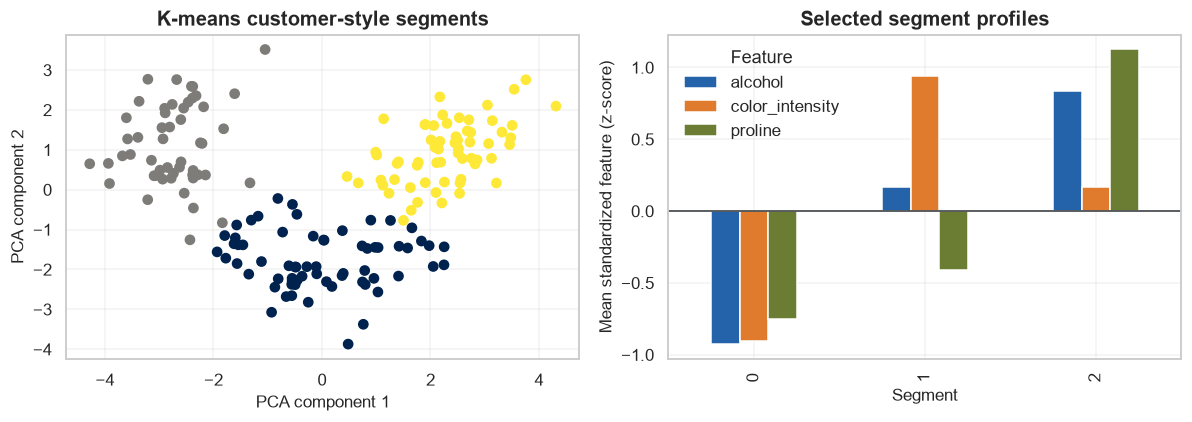

In [3]:
from sklearn.cluster import KMeans
from sklearn.datasets import load_wine
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score
from sklearn.mixture import GaussianMixture
from sklearn.preprocessing import StandardScaler

wine=load_wine(as_frame=True)
print("Rows/features:",wine.data.shape,"missing:",int(wine.data.isna().sum().sum()))
display(wine.data.describe().loc[["mean","std"]].round(2))
scaler=StandardScaler(); X=scaler.fit_transform(wine.data)
scratch_labels,scratch_centroids=kmeans_scratch(X,3)
kmeans=KMeans(n_clusters=3,n_init=20,random_state=RANDOM_SEED).fit(X)
gmm=GaussianMixture(n_components=3,random_state=RANDOM_SEED).fit(X); gmm_labels=gmm.predict(X)
comparison=pd.DataFrame([
    {"model":"Scratch K-means","silhouette":silhouette_score(X,scratch_labels)},
    {"model":"Library K-means","silhouette":silhouette_score(X,kmeans.labels_)},
    {"model":"Gaussian mixture","silhouette":silhouette_score(X,gmm_labels)},
]).sort_values("silhouette",ascending=False)
display(comparison.round(3))
projection=PCA(n_components=2).fit_transform(X)
figure,axes=plt.subplots(1,2,figsize=(11,4))
axes[0].scatter(projection[:,0],projection[:,1],c=kmeans.labels_,cmap="cividis"); axes[0].set(title="K-means customer-style segments",xlabel="PCA component 1",ylabel="PCA component 2")
standardized_frame=pd.DataFrame(X,columns=wine.feature_names).assign(segment=kmeans.labels_)
profile=standardized_frame.groupby("segment").mean()[["alcohol","color_intensity","proline"]]
profile.plot.bar(ax=axes[1],color=[COURSE_COLORS["blue"],COURSE_COLORS["orange"],COURSE_COLORS["olive"]])
axes[1].axhline(0,color=COURSE_COLORS["charcoal"],linewidth=1)
axes[1].set(title="Selected segment profiles",xlabel="Segment",ylabel="Mean standardized feature (z-score)"); axes[1].legend(title="Feature")
figure.tight_layout(); plt.show()

**How to interpret the result:** PCA shows a lossy view of groups while the profile chart returns to original feature units for interpretation.

**Scratch-to-library comparison:**

- **Performance:** the educational implementation favors visible steps; the library implementation uses optimized, vectorized, and often compiled routines.
- **Numerical stability:** production libraries add convergence checks, guarded arithmetic, and tested handling of edge cases that the compact scratch version intentionally omits.
- **Flexibility:** scratch code is easy to inspect and change for one lesson, while the library version supports reusable estimator interfaces, pipelines, and broader input cases.
- **Complexity:** the scratch implementation makes the central mechanism explicit; the library hides additional validation and engineering complexity behind a small public API.

Compare the measured outputs above rather than expecting exact equality: initialization, stopping rules, regularization, and implementation details can differ.

## 17. Hyperparameter experiments

The number of groups is compared with silhouette and inertia; interpretability and stability remain required.

,k,silhouette,inertia
0,2,0.259,1658.759
1,3,0.285,1277.928
2,4,0.259,1175.352
3,5,0.232,1107.007
4,6,0.237,1046.002
5,7,0.204,981.595


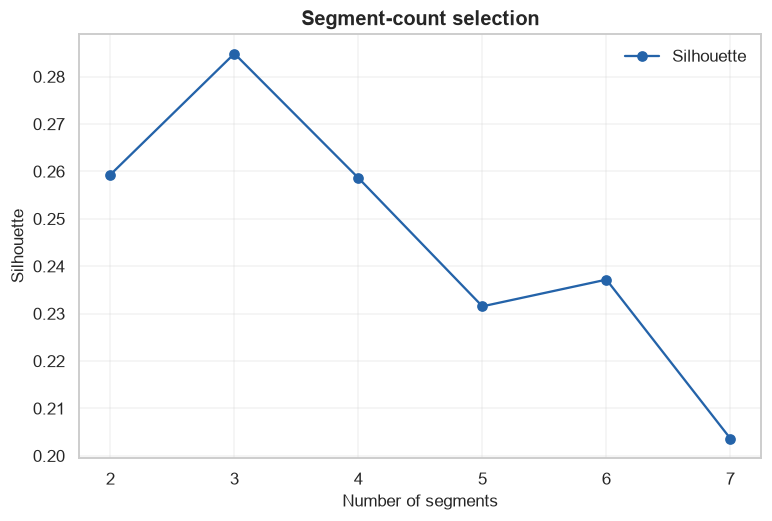

In [4]:
rows=[]
for k in range(2,8):
    model=KMeans(n_clusters=k,n_init=20,random_state=RANDOM_SEED).fit(X)
    rows.append({"k":k,"silhouette":silhouette_score(X,model.labels_),"inertia":model.inertia_})
tuning=pd.DataFrame(rows); display(tuning.round(3))
figure,axis=plt.subplots(); axis.plot(tuning["k"],tuning["silhouette"],marker="o",color=COURSE_COLORS["blue"],label="Silhouette")
axis.set(title="Segment-count selection",xlabel="Number of segments",ylabel="Silhouette"); axis.legend(); plt.show()

## 18. Common mistakes

            - Starting with a model before defining success
- Fitting preprocessing before splitting
- Selecting on test performance
- Hiding failure modes behind one aggregate score

            ## 19. Advantages and disadvantages

            **Advantages**

            - Reproducible end-to-end evidence
- Explicit comparison and limitations

            **Disadvantages**

            - Benchmark data does not prove deployment readiness
- Offline metrics omit operational costs

            ## 20. When to use and when not to use the algorithm

            **Use it when:** the dataset, metric, and decision are aligned and the result will be treated as evidence rather than certainty.

            **Do not use it when:** segments would drive consequential decisions without stability checks, domain review, privacy analysis, and outcome validation.

## 21. Exercises

1. **Conceptual:** Which decision does the model support?
2. **Mathematical/hand calculation:** Recalculate the primary metric on a tiny example by hand.
3. **Coding/experimentation:** Repeat the final comparison over multiple seeds or splits.

<details>
<summary><strong>22. Exercise solutions</strong></summary>

1. State the user, action, model output, and consequence in one sentence.
2. Apply the displayed metric to each example, sum, and divide by the correct denominator.
3. Keep preprocessing and candidate definitions fixed, report every run, and summarize mean plus variability.

</details>

## Capstone delivery checklist

- **Business or real-world problem and success metric:** defined before modeling in the problem-definition section.
- **Dataset description and exploratory data analysis:** documented beside the bounded dataset preview and audit outputs.
- **Data cleaning and feature engineering:** performed after the split where fitting or target information could otherwise leak; choices are stated explicitly, including when no cleaning is required.
- **Baseline and multiple-model comparison:** a simple reference model is evaluated before more flexible candidates.
- **Hyperparameter tuning:** candidates are selected only with development or validation evidence.
- **Final evaluation and error analysis:** the frozen choice is assessed on untouched data with a task-appropriate diagnostic plot.
- **Limitations and possible improvements:** recorded with the disadvantages and interpretation so the result is not overstated.
- **Final conclusion:** the summary connects the evidence, limitations, and next steps.

## 23. Summary and key takeaways

            - The workflow is part of the model
- Baselines and data leakage checks precede tuning
- Final evaluation uses untouched data
- Error analysis, limitations, and possible improvements belong in the conclusion

            ## 24. Further reading

            - [scikit-learn model selection](https://scikit-learn.org/stable/model_selection.html)
- [PyTorch tutorials](https://pytorch.org/tutorials/)